# Sports Analytics Series: Winter Olympics Deep Dive

In this workshop, we will explore:

- How Olympic medals are distributed
- Whether dominance has increased over time
- The effect of hosting on performance
- The role of superstar athletes
- Whether human performance is still improving

All analysis is based on real Winter Olympic data (2002–2026).

## Extracting Macro-Data from 2026 Winter Olympics

In [1]:
import numpy as np
import requests
import pandas as pd
from io import StringIO

winter_urls = {
    2002: "https://en.wikipedia.org/wiki/2002_Winter_Olympics_medal_table",
    2006: "https://en.wikipedia.org/wiki/2006_Winter_Olympics_medal_table",
    2010: "https://en.wikipedia.org/wiki/2010_Winter_Olympics_medal_table",
    2014: "https://en.wikipedia.org/wiki/2014_Winter_Olympics_medal_table",
    2018: "https://en.wikipedia.org/wiki/2018_Winter_Olympics_medal_table",
    2022: "https://en.wikipedia.org/wiki/2022_Winter_Olympics_medal_table",
    2026: "https://en.wikipedia.org/wiki/2026_Winter_Olympics_medal_table",
}

headers = {"User-Agent": "Mozilla/5.0"}

def normalize_columns(cols):
    """
    Converts columns to simple strings (handles multi-index columns),
    lowercases them, replaces spaces with underscores.
    """
    out = []
    for c in cols:
        if isinstance(c, tuple):
            c = "_".join([str(x) for x in c if x and x != "nan"])
        c = str(c).strip().lower().replace(" ", "_")
        out.append(c)
    return out

def extract_medal_table(html, year):
    """
    Finds the medal table on a Wikipedia medal-table page and returns a standardized DataFrame:
    columns: country, gold, silver, bronze, total, year
    """
    # Future-proof: pass a file-like object instead of raw string
    tables = pd.read_html(StringIO(html))

    # Choose the table that contains Gold/Silver/Bronze/Total
    candidate = None
    for t in tables:
        cols = normalize_columns(t.columns)
        joined = " ".join(cols)
        if ("gold" in joined) and ("silver" in joined) and ("bronze" in joined) and ("total" in joined):
            candidate = t.copy()
            candidate.columns = cols
            break

    if candidate is None:
        raise ValueError(f"Could not find medal table for year {year}")

    df = candidate

    # Find the country/team column (often 'nation', 'noc', or 'team')
    country_col = None
    for c in df.columns:
        if any(key in c for key in ["nation", "noc", "team", "country"]):
            country_col = c
            break
    if country_col is None:
        raise ValueError(f"Could not find country column for year {year}. Columns: {df.columns.tolist()}")

    # Standardize and keep only required columns
    keep_map = {
        country_col: "country",
        "gold": "gold",
        "silver": "silver",
        "bronze": "bronze",
        "total": "total",
    }

    # Some tables might have columns like 'gold.1' etc; handle by choosing first match
    def first_col_containing(keyword):
        matches = [c for c in df.columns if c == keyword or c.startswith(keyword + "_") or c.startswith(keyword + ".")]
        if keyword in df.columns:
            return keyword
        if matches:
            return matches[0]
        # fallback: contains
        matches = [c for c in df.columns if keyword in c]
        return matches[0] if matches else None

    gold_col = first_col_containing("gold")
    silver_col = first_col_containing("silver")
    bronze_col = first_col_containing("bronze")
    total_col = first_col_containing("total")

    needed = [country_col, gold_col, silver_col, bronze_col, total_col]
    if any(x is None for x in needed):
        raise ValueError(f"Missing medal columns for year {year}. Columns: {df.columns.tolist()}")

    out = df[[country_col, gold_col, silver_col, bronze_col, total_col]].copy()
    out.columns = ["country", "gold", "silver", "bronze", "total"]

    # Clean numeric columns (sometimes strings/footnotes)
    for c in ["gold", "silver", "bronze", "total"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # Drop rows that aren't countries (NaNs in total after coercion)
    out = out.dropna(subset=["total"])

    # Ensure integers
    out[["gold", "silver", "bronze", "total"]] = out[["gold", "silver", "bronze", "total"]].astype(int)

    out["year"] = year
    return out

all_years = []
for year, url in winter_urls.items():
    html = requests.get(url, headers=headers).text
    df_year = extract_medal_table(html, year)
    all_years.append(df_year)

winter_medals = pd.concat(all_years, ignore_index=True)

print("Final shape:", winter_medals.shape)
print("Years:", sorted(winter_medals["year"].unique()))
winter_medals.head()

Final shape: (198, 6)
Years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022), np.int64(2026)]


,country,gold,silver,bronze,total,year
0,Norway‡,13,5,7,25,2002
1,Germany,12,16,8,36,2002
2,United States*,10,13,11,34,2002
3,Canada,7,3,7,17,2002
4,Russia,5,4,4,13,2002


## Cleaning the Dataset for Analysis

In [2]:
import re

winter_medals["country"] = (
    winter_medals["country"]
    .astype(str)
    .str.replace(r"\[.*?\]", "", regex=True)      # remove bracketed footnotes like [a]
    .str.replace(r"[†‡*]+", "", regex=True)       # remove dagger/star symbols
    .str.replace(r"\s+", " ", regex=True)         # collapse multiple spaces
    .str.strip()
)

winter_medals["country"].head(10)

,country
0,Norway
1,Germany
2,United States
3,Canada
4,Russia
5,France
6,Italy
7,Finland
8,Netherlands
9,Austria


## Double Check to confirm Dataset

In [3]:
print("Shape:", winter_medals.shape)
print("Countries per year:")
print(winter_medals.groupby("year")["country"].nunique())

Shape: (198, 6)
Countries per year:
year
2002    25
2006    27
2010    27
2014    27
2018    31
2022    30
2026    31
Name: country, dtype: int64


In [4]:
winter_medals.groupby("year")["total"].sum()

,total
year,
2002,468
2006,504
2010,516
2014,590
2018,614
2022,656
2026,698


## How Are Medals Distributed?

We begin by examining how medals are distributed across countries in a single Olympic year.

Are medals evenly distributed, or concentrated among a few nations?

In [5]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# Remove summary rows like "Totals (29 entries)"
winter_medals = winter_medals[
    ~winter_medals["country"].str.contains(r"(?i)total", na=False)
].copy()

# Reset index
winter_medals.reset_index(drop=True, inplace=True)

# Quick verification
winter_medals.groupby("year")["total"].max()

sns.set_theme(style="whitegrid", context="talk")

years = sorted(winter_medals["year"].unique())

year_dropdown = widgets.Dropdown(
    options=years,
    value=2026,
    description="Year:"
)

out = widgets.Output()

def update(change=None):
    with out:
        clear_output(wait=True)

        y = year_dropdown.value
        df = winter_medals[winter_medals["year"] == y].copy()

        # Sort descending
        df_sorted = df.sort_values("total", ascending=False)

        # Compute concentration metrics
        total_medals = df_sorted["total"].sum()
        top1 = df_sorted.iloc[0]["total"] / total_medals
        top5 = df_sorted["total"].head(5).sum() / total_medals
        top10 = df_sorted["total"].head(10).sum() / total_medals

        print(f"Year: {y}")
        print(f"Countries: {df.shape[0]}")
        print(f"Top 1 Share:  {top1:.1%}")
        print(f"Top 5 Share:  {top5:.1%}")
        print(f"Top 10 Share: {top10:.1%}")

        # Histogram
        plt.figure(figsize=(8,4))
        sns.histplot(df["total"], bins=12, kde=True)
        plt.title(f"Distribution of Total Medals ({y})")
        plt.xlabel("Total Medals")
        plt.ylabel("Number of Countries")
        plt.show()

        # Top 10 Bar Chart
        top10_df = df_sorted.head(10)
        plt.figure(figsize=(8,5))
        sns.barplot(data=top10_df, x="total", y="country")
        plt.title(f"Top 10 Countries by Total Medals ({y})")
        plt.xlabel("Total Medals")
        plt.ylabel("Country")
        plt.show()

year_dropdown.observe(update, names="value")
display(year_dropdown, out)
update()

Dropdown(description='Year:', index=6, options=(np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)…

Output()

## Quick check to make sure data is consistent

In [6]:
winter_medals[winter_medals["year"] == 2026]["total"].sum()

np.int64(349)

In [7]:
print("2026 sum:", winter_medals[winter_medals["year"] == 2026]["total"].sum())
print("Max medals country 2026:", winter_medals[winter_medals["year"] == 2026]["total"].max())

2026 sum: 349
Max medals country 2026: 41


## How Are Medals Distributed?

We begin by examining how medals are distributed across countries in a single Olympic year.

Are medals evenly distributed, or concentrated among a few nations?

In [8]:
concentration_results = []

years = sorted(winter_medals["year"].unique())

for y in years:
    df = winter_medals[winter_medals["year"] == y].copy()
    df_sorted = df.sort_values("total", ascending=False)

    total_medals = df_sorted["total"].sum()

    top1_share = df_sorted.iloc[0]["total"] / total_medals
    top5_share = df_sorted["total"].head(5).sum() / total_medals
    top10_share = df_sorted["total"].head(10).sum() / total_medals

    concentration_results.append({
        "year": y,
        "top1_share": top1_share,
        "top5_share": top5_share,
        "top10_share": top10_share
    })

concentration_df = pd.DataFrame(concentration_results)

concentration_df

,year,top1_share,top5_share,top10_share
0,2002,0.153846,0.551282,0.790598
1,2006,0.115079,0.488095,0.761905
2,2010,0.143411,0.515504,0.751938
3,2014,0.098305,0.450847,0.711864
4,2018,0.127036,0.462541,0.716612
5,2022,0.112805,0.448171,0.716463
6,2026,0.117479,0.441261,0.742120


## Plotting concentration over time

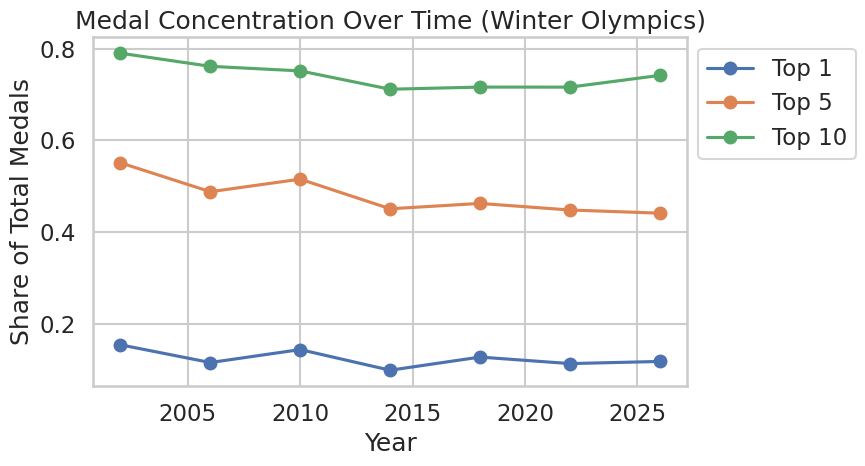

In [9]:
plt.figure(figsize=(9,5))

plt.plot(concentration_df["year"], concentration_df["top1_share"], marker="o", label="Top 1")
plt.plot(concentration_df["year"], concentration_df["top5_share"], marker="o", label="Top 5")
plt.plot(concentration_df["year"], concentration_df["top10_share"], marker="o", label="Top 10")

plt.title("Medal Concentration Over Time (Winter Olympics)")
plt.xlabel("Year")
plt.ylabel("Share of Total Medals")

# Move legend outside
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## Further comparison

In [10]:
# Separate 2026 from historical years
historical_df = concentration_df[concentration_df["year"] < 2026]
year_2026 = concentration_df[concentration_df["year"] == 2026]

# Compute historical averages
historical_means = historical_df[["top1_share", "top5_share", "top10_share"]].mean()

print("Historical Averages (2002–2022):")
print(historical_means)

print("\n2026 Values:")
print(year_2026[["top1_share", "top5_share", "top10_share"]])

Historical Averages (2002–2022):
top1_share     0.125080
top5_share     0.486073
top10_share    0.741564
dtype: float64

2026 Values:
   top1_share  top5_share  top10_share
6    0.117479    0.441261      0.74212


## Visualize Comparison

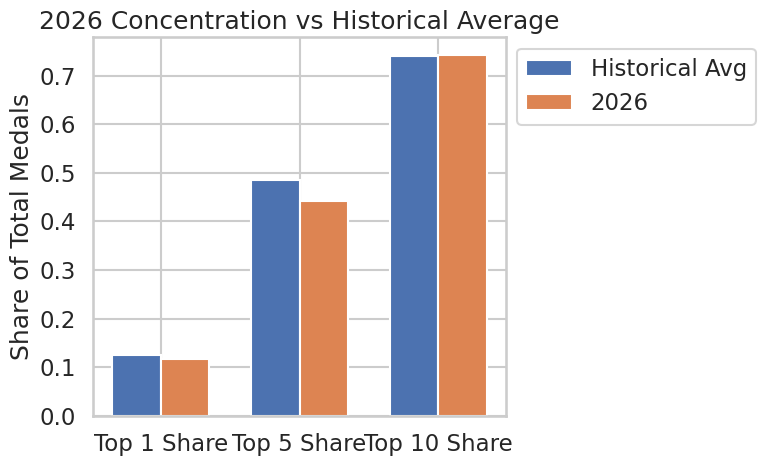

array([-0.00760185, -0.0448126 ,  0.0005568 ])

In [11]:
import numpy as np

labels = ["Top 1 Share", "Top 5 Share", "Top 10 Share"]
historical_values = historical_means[["top1_share", "top5_share", "top10_share"]].values
values_2026 = year_2026[["top1_share", "top5_share", "top10_share"]].values.flatten()

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, historical_values, width, label="Historical Avg")
plt.bar(x + width/2, values_2026, width, label="2026")

plt.xticks(x, labels)
plt.ylabel("Share of Total Medals")
plt.title("2026 Concentration vs Historical Average")

# Move legend outside
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

(values_2026 - historical_values)

## 🌍 Country Spotlight

Select a country to compare its 2026 performance to its historical record.

In [12]:
country_list = sorted(winter_medals["country"].unique())

country_dropdown = widgets.Dropdown(
    options=country_list,
    value="Norway",
    description="Country:"
)

output_country = widgets.Output()

def update_country(change=None):
    with output_country:
        clear_output(wait=True)

        selected_country = country_dropdown.value

        df_country = winter_medals[winter_medals["country"] == selected_country].sort_values("year")

        # Plot medal trend
        plt.figure(figsize=(8,5))
        plt.plot(df_country["year"], df_country["total"], marker="o")
        plt.title(f"{selected_country} - Medal Trend Over Time")
        plt.xlabel("Year")
        plt.ylabel("Total Medals")
        plt.show()

        # Compare 2026 vs historical average
        if 2026 in df_country["year"].values:
            medals_2026 = df_country[df_country["year"] == 2026]["total"].values[0]
            historical_avg = df_country[df_country["year"] < 2026]["total"].mean()

            print(f"2026 Medals: {medals_2026}")
            print(f"Historical Average (pre-2026): {historical_avg:.2f}")

            diff = medals_2026 - historical_avg
            print(f"Difference: {diff:.2f}")

country_dropdown.observe(update_country, names="value")

display(country_dropdown, output_country)
update_country()

Dropdown(description='Country:', index=26, options=('Australia', 'Austria', 'Belarus', 'Belgium', 'Brazil', 'B…

Output()

##  Does Hosting Provide an Advantage?

We compare each host country’s medal count during its host year
to its prior historical average.

This isolates the potential “host boost” effect.

In [13]:
# Create host mapping
host_map = {
    2002: "United States",
    2006: "Italy",
    2010: "Canada",
    2014: "Russia",
    2018: "South Korea",
    2022: "China",
    2026: "Italy"
}

# Add host indicator
winter_medals["is_host"] = winter_medals.apply(
    lambda row: 1 if host_map.get(row["year"]) == row["country"] else 0,
    axis=1
)

winter_medals.head()

,country,gold,silver,bronze,total,year,is_host
0,Norway,13,5,7,25,2002,0
1,Germany,12,16,8,36,2002,0
2,United States,10,13,11,34,2002,1
3,Canada,7,3,7,17,2002,0
4,Russia,5,4,4,13,2002,0


## Comparison to Other Host Countries

In [14]:
host_results_prior = []

for year, host_country in host_map.items():
    df_country = winter_medals[winter_medals["country"] == host_country].sort_values("year")

    # Skip if no data
    if year not in df_country["year"].values:
        continue

    # Host year medals
    host_year_medals = df_country[df_country["year"] == year]["total"].values[0]

    # Only use prior years
    prior_years = df_country[df_country["year"] < year]

    # If no prior years exist (unlikely here), skip
    if len(prior_years) == 0:
        continue

    prior_avg = prior_years["total"].mean()

    host_results_prior.append({
        "year": year,
        "host_country": host_country,
        "host_medals": host_year_medals,
        "prior_avg": prior_avg,
        "difference": host_year_medals - prior_avg
    })

host_df_prior = pd.DataFrame(host_results_prior)
host_df_prior

,year,host_country,host_medals,prior_avg,difference
0,2006,Italy,11,13.000000,-2.000000
1,2010,Canada,26,20.500000,5.500000
2,2014,Russia,29,16.000000,13.000000
3,2018,South Korea,17,9.250000,7.750000
4,2022,China,15,9.600000,5.400000
5,2026,Italy,30,10.666667,19.333333


## Visualizing the Comparison between Host Countries

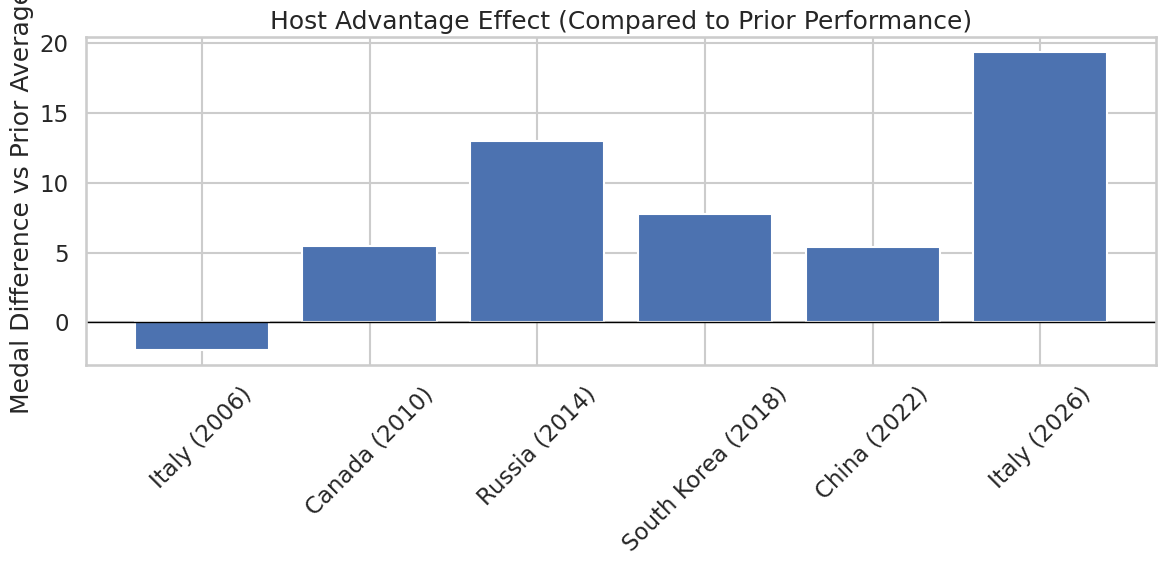

In [15]:
plt.figure(figsize=(12,6))  # wider and taller

labels = host_df_prior["host_country"] + " (" + host_df_prior["year"].astype(str) + ")"

plt.bar(labels, host_df_prior["difference"])

plt.xticks(rotation=45)
plt.ylabel("Medal Difference vs Prior Average")
plt.title("Host Advantage Effect (Compared to Prior Performance)")
plt.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

## Systems vs Superstars

Do countries succeed through deep national systems,
or are they driven by one dominant athlete?

We measure each country's reliance on its top medal winner.

## Load Datasets

In [16]:
import requests
from io import StringIO
import pandas as pd

url_2026_medalists = "https://en.wikipedia.org/wiki/List_of_2026_Winter_Olympics_medal_winners"

headers = {"User-Agent": "Mozilla/5.0"}

html = requests.get(url_2026_medalists, headers=headers).text
tables = pd.read_html(StringIO(html))

len(tables)



33

In [17]:
tables[0].head()
tables[0].columns

Index([0], dtype='int64')

## Double Check Dataset is valid

In [18]:
for i, table in enumerate(tables):
    print(f"\nTable {i}")
    print(table.head())
    print(table.columns)


Table 0
                                                   0
0                                Part of a series on
1                               2026 Winter Olympics
2  Bid process (bid details) Development (venues,...
3                                                vte
Index([0], dtype='int64')

Table 1
                                                   0  \
0                                           Contents   
1  Alpine skiing Biathlon Bobsleigh Cross-country...   
2              Changes in medals See also References   

                                                   1  \
0                                           Contents   
1  Figure skating Freestyle skiing Ice hockey Lug...   
2              Changes in medals See also References   

                                                   2  
0                                           Contents  
1  Short-track speed skating Skeleton Ski jumping...  
2              Changes in medals See also References  
Index([0, 1, 2], dtyp

## Cleaning Data

In [19]:
import numpy as np
import pandas as pd
import re

# Map table index -> sport (based on your printed output)
def sport_from_table_idx(i: int) -> str:
    if i in [2, 3]: return "Alpine skiing"
    if i in [4, 5, 6]: return "Biathlon"
    if i in [7]: return "Bobsleigh"
    if i in [8, 9]: return "Cross-country skiing"
    if i in [10]: return "Curling"
    if i in [11]: return "Figure skating"
    if i in [12, 13, 14]: return "Freestyle skiing"
    if i in [15]: return "Ice hockey"
    if i in [16]: return "Luge"
    if i in [17]: return "Nordic combined"
    if i in [18, 19, 20]: return "Short track speed skating"
    if i in [21]: return "Skeleton"
    if i in [22, 23, 24]: return "Ski jumping"
    if i in [25]: return "Ski mountaineering"
    if i in [26, 27, 28]: return "Snowboarding"
    if i in [29, 30]: return "Speed skating"
    return "Unknown"

In [20]:
def parse_medal_cell(cell):
    """
    Returns (athlete_or_team, country) from a Wikipedia medal cell.
    Handles:
      - 'Name  Country'
      - 'Country Name1 Name2...' (team entries)
      - 'Not awarded'
      - NaN
    """
    if pd.isna(cell):
        return (np.nan, np.nan)

    s = str(cell).strip()

    # Remove bracketed footnotes like [a]
    s = re.sub(r"\[.*?\]", "", s).strip()

    if s.lower().startswith("not awarded"):
        return (np.nan, np.nan)

    # Wikipedia often uses a non-breaking space between name and country
    # We'll split on any whitespace, but keep the *last* token as country when it's "Name ... Country"
    # For team rows like "Norway Name1 Name2", the first token is the country.

    parts = s.split()
    if len(parts) < 2:
        return (s, np.nan)

    # Heuristic:
    # If first token looks like a country-start (e.g., 'Norway', 'France', 'Germany', 'Italy'),
    # treat first token as country for team entries.
    # Otherwise treat last token(s) as country is hard because of multi-word countries
    # so we handle multi-word countries via a known list.
    multi_word_countries = {
        "United States", "South Korea", "Czech Republic", "Great Britain",
        "New Zealand", "Individual Neutral Athletes"
    }

    # Try match multi-word countries at end first
    for c in sorted(multi_word_countries, key=len, reverse=True):
        if s.endswith(c):
            athlete = s[: -len(c)].strip()
            country = c
            return (athlete, country)

    # If no multi-word match, assume last token is country for single-word countries
    athlete = " ".join(parts[:-1]).strip()
    country = parts[-1].strip()
    return (athlete, country)

In [21]:
rows = []

for i in range(2, 31):  # medal tables range you found
    t = tables[i].copy()

    # Standardize expected columns
    expected = {"Event", "Gold", "Silver", "Bronze"}
    if set(t.columns) != expected:
        # Some tables may still match but in different order; handle flexibly
        cols = [c for c in ["Event", "Gold", "Silver", "Bronze"] if c in t.columns]
        if len(cols) != 4:
            continue
        t = t[cols]

    sport = sport_from_table_idx(i)

    for _, r in t.iterrows():
        event = str(r["Event"]).replace("details", "").strip()

        for medal in ["Gold", "Silver", "Bronze"]:
            athlete, country = parse_medal_cell(r[medal])

            if pd.isna(country) or pd.isna(athlete):
                continue

            rows.append({
                "year": 2026,
                "sport": sport,
                "event": event,
                "medal": medal.lower(),     # gold/silver/bronze
                "athlete_or_team": athlete,
                "country": country
            })

medalists_2026 = pd.DataFrame(rows)

print("Rows:", medalists_2026.shape[0])
medalists_2026.head(10)

Rows: 346


,year,sport,event,medal,athlete_or_team,country
0,2026,Alpine skiing,Downhill,gold,Franjo von Allmen,Switzerland
1,2026,Alpine skiing,Downhill,silver,Giovanni Franzoni,Italy
2,2026,Alpine skiing,Downhill,bronze,Dominik Paris,Italy
3,2026,Alpine skiing,Super-G,gold,Franjo von Allmen,Switzerland
4,2026,Alpine skiing,Super-G,silver,Ryan Cochran-Siegle,United States
5,2026,Alpine skiing,Super-G,bronze,Marco Odermatt,Switzerland
6,2026,Alpine skiing,Giant slalom,gold,Lucas Pinheiro Braathen,Brazil
7,2026,Alpine skiing,Giant slalom,silver,Marco Odermatt,Switzerland
8,2026,Alpine skiing,Giant slalom,bronze,Loïc Meillard,Switzerland
9,2026,Alpine skiing,Slalom,gold,Loïc Meillard,Switzerland


In [22]:
# Count medals per athlete/team within country
athlete_counts = (
    medalists_2026
    .groupby(["country", "athlete_or_team"])
    .size()
    .reset_index(name="medals_won")
)

# For each country, find the top medal-winning athlete/team
top_athlete_by_country = (
    athlete_counts
    .sort_values(["country", "medals_won"], ascending=[True, False])
    .groupby("country")
    .head(1)
    .rename(columns={"athlete_or_team": "top_athlete_or_team"})
)

# Merge with macro totals for 2026
macro_2026 = winter_medals[winter_medals["year"] == 2026][["country", "total"]].rename(columns={"total": "country_total_medals"})

superstar_df = top_athlete_by_country.merge(macro_2026, on="country", how="left")
superstar_df["top_athlete_share"] = superstar_df["medals_won"] / superstar_df["country_total_medals"]

# Countries where the top athlete accounts for a big chunk
superstar_df.sort_values("top_athlete_share", ascending=False).head(15)

,country,top_athlete_or_team,medals_won,country_total_medals,top_athlete_share
12,Brazil,Lucas Pinheiro Braathen,1,1.0,1.000000
25,Denmark,Viktor Hald Thorup,1,1.0,1.000000
31,Estonia,Henry Sildaru,1,1.0,1.000000
43,Individual Neutral Athletes,Nikita Filippov,1,1.0,1.000000
51,Kazakhstan,Mikhail Shaidorov,1,1.0,1.000000
73,New Zealand,Zoi Sadowski-Synnott,2,3.0,0.666667
59,Latvia,Elīna Ieva Bota,1,2.0,0.500000
96,Slovenia,Nika Prevc,2,4.0,0.500000
81,Poland,Kacper Tomasiak,2,4.0,0.500000
14,Bulgaria,Lora Hristova,1,2.0,0.500000


In [23]:
# Check weird/missing countries
medalists_2026["country"].value_counts().head(15)

# Check if any rows still contain 'details' or bracket footnotes
medalists_2026[medalists_2026["athlete_or_team"].str.contains(r"\[", na=False)].head()

,year,sport,event,medal,athlete_or_team,country


In [24]:
medalists_2026.head()

,year,sport,event,medal,athlete_or_team,country
0,2026,Alpine skiing,Downhill,gold,Franjo von Allmen,Switzerland
1,2026,Alpine skiing,Downhill,silver,Giovanni Franzoni,Italy
2,2026,Alpine skiing,Downhill,bronze,Dominik Paris,Italy
3,2026,Alpine skiing,Super-G,gold,Franjo von Allmen,Switzerland
4,2026,Alpine skiing,Super-G,silver,Ryan Cochran-Siegle,United States


## Clean rebuild of dataset

In [25]:
# Count medals per athlete/team within each country
# --- Recompute athlete medal counts ---
athlete_counts = (
    medalists_2026
    .groupby(["country", "athlete_or_team"])
    .size()
    .reset_index(name="medals_won")
)

# --- Identify top medal winner per country ---
top_athletes = (
    athlete_counts
    .sort_values(["country", "medals_won"], ascending=[True, False])
    .groupby("country")
    .head(1)
    .rename(columns={"athlete_or_team": "top_athlete"})
)

# --- Get macro totals for 2026 ---
macro_2026 = (
    winter_medals[winter_medals["year"] == 2026]
    [["country", "total"]]
    .rename(columns={"total": "country_total_medals"})
)

# --- Merge ---
superstar_df = top_athletes.merge(macro_2026, on="country", how="left")

# --- Compute share ---
superstar_df["top_athlete_share"] = (
    superstar_df["medals_won"] / superstar_df["country_total_medals"]
)

# --- FILTER: Only countries with at least 3 medals ---
filtered_superstar = superstar_df[
    superstar_df["country_total_medals"] >= 3
].copy()

# --- Sort and inspect ---
filtered_superstar = filtered_superstar.sort_values(
    "top_athlete_share", ascending=False
)

filtered_superstar.head(15)

,country,top_athlete,medals_won,country_total_medals,top_athlete_share
73,New Zealand,Zoi Sadowski-Synnott,2,3.0,0.666667
81,Poland,Kacper Tomasiak,2,4.0,0.500000
96,Slovenia,Nika Prevc,2,4.0,0.500000
24,Czech Republic,Metoděj Jílek,2,5.0,0.400000
98,Spain,Ana Alonso,1,3.0,0.333333
97,South Korea,Kim Gil-li,2,10.0,0.200000
38,Great Britain,Matt Weston,1,5.0,0.200000
18,China,Eileen Gu,3,15.0,0.200000
4,Australia,Cooper Woods-Topalovic,1,6.0,0.166667
33,Finland,Eero Hirvonen,1,6.0,0.166667


## Visualization

## Bubble Chart

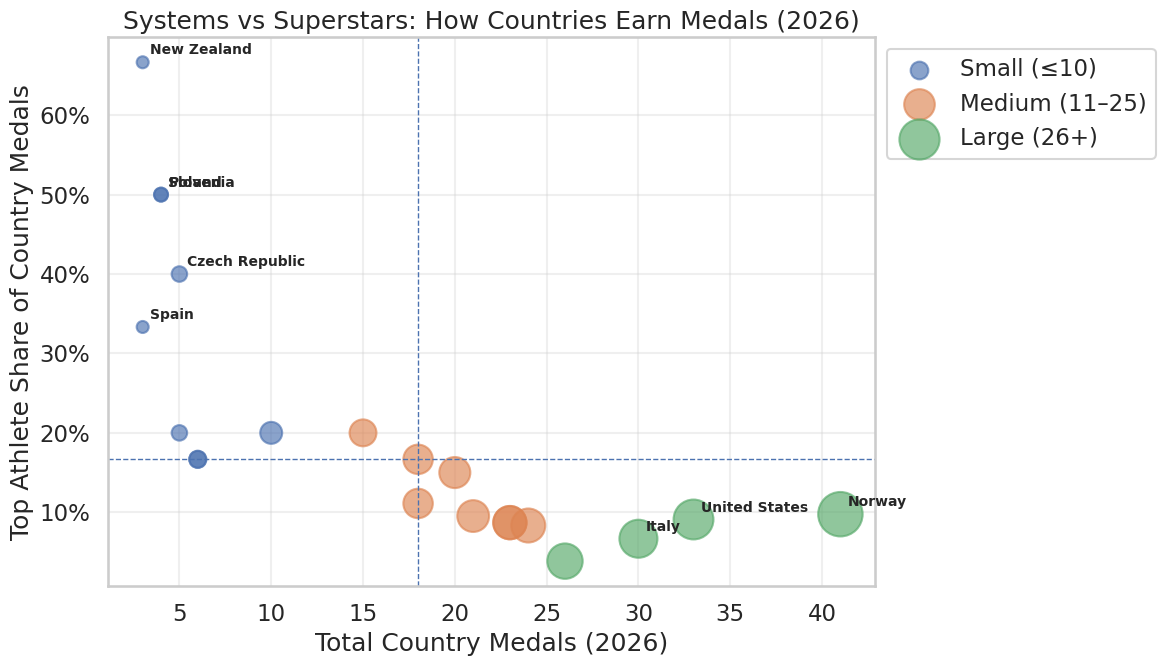

In [26]:
import matplotlib.ticker as mtick

plot_df = filtered_superstar.copy()

# --- 1) Create medal tiers for color grouping ---
# You can tweak these bins if you want
bins = [0, 10, 25, plot_df["country_total_medals"].max() + 1]
labels = ["Small (≤10)", "Medium (11–25)", "Large (26+)"]
plot_df["tier"] = pd.cut(plot_df["country_total_medals"], bins=bins, labels=labels, right=True)

tier_to_marker_size = {"Small (≤10)": 120, "Medium (11–25)": 260, "Large (26+)": 500}

plt.figure(figsize=(12,7))

# --- 2) Plot each tier separately (gives legend + clearer story) ---
for tier in labels:
    df_t = plot_df[plot_df["tier"] == tier]
    plt.scatter(
        df_t["country_total_medals"],
        df_t["top_athlete_share"],
        s=df_t["country_total_medals"] * 25,  # keep proportional bubble size
        alpha=0.65,
        label=tier
    )

# --- 3) Add reference lines (medians) for dramatic quadrant framing ---
x_med = plot_df["country_total_medals"].median()
y_med = plot_df["top_athlete_share"].median()

plt.axvline(x_med, linestyle="--", linewidth=1)
plt.axhline(y_med, linestyle="--", linewidth=1)

# --- 4) Label only the extreme points ---
# Top dependency countries
top_dep = plot_df.sort_values("top_athlete_share", ascending=False).head(5)

# Most medals countries
top_medals = plot_df.sort_values("country_total_medals", ascending=False).head(3)

label_df = pd.concat([top_dep, top_medals]).drop_duplicates()

for _, r in label_df.iterrows():
    plt.text(
        r["country_total_medals"] + 0.4,
        r["top_athlete_share"] + 0.01,
        r["country"],
        fontsize=10,
        weight="bold"
    )

# --- formatting ---
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel("Total Country Medals (2026)")
plt.ylabel("Top Athlete Share of Country Medals")
plt.title("Systems vs Superstars: How Countries Earn Medals (2026)")

# Put legend outside
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Lollipop Chart

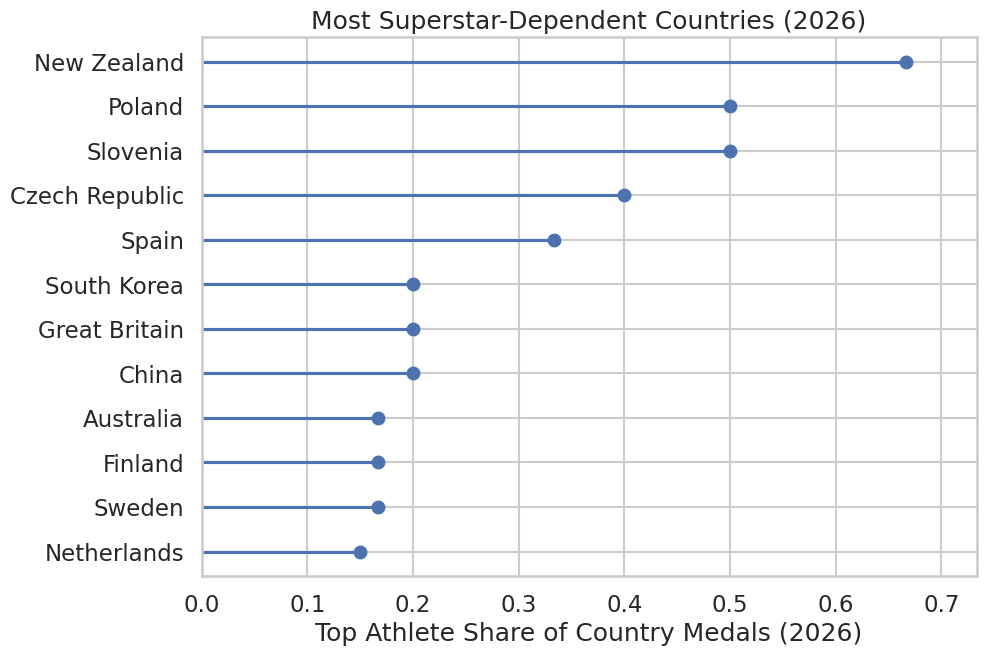

In [27]:
import matplotlib.pyplot as plt

# Use filtered data (≥ 3 medals)
lollipop_df = filtered_superstar.sort_values("top_athlete_share", ascending=False)

# Only show top 12 for clarity
lollipop_df = lollipop_df.head(12)

plt.figure(figsize=(10,7))

# Draw lines
plt.hlines(
    y=lollipop_df["country"],
    xmin=0,
    xmax=lollipop_df["top_athlete_share"]
)

# Draw points
plt.plot(
    lollipop_df["top_athlete_share"],
    lollipop_df["country"],
    "o"
)

plt.xlabel("Top Athlete Share of Country Medals (2026)")
plt.title("Most Superstar-Dependent Countries (2026)")
plt.gca().invert_yaxis()

plt.xlim(0, lollipop_df["top_athlete_share"].max() * 1.1)

plt.show()

## Human Limits in Elite Performance

We examine how winning times in the 500m event
have evolved over the past two decades.

Performance gains at this level are measured in tenths — or even hundredths — of a second.

In [28]:
speed500_urls = {
    2002: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2002_Winter_Olympics_–_Men%27s_500_metres",
    2006: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2006_Winter_Olympics_–_Men%27s_500_metres",
    2010: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2010_Winter_Olympics_–_Men%27s_500_metres",
    2014: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2014_Winter_Olympics_–_Men%27s_500_metres",
    2018: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2018_Winter_Olympics_–_Men%27s_500_metres",
    2022: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2022_Winter_Olympics_–_Men%27s_500_metres",
    2026: "https://en.wikipedia.org/wiki/Speed_skating_at_the_2026_Winter_Olympics_–_Men%27s_500_metres",
}

In [29]:
import requests
from io import StringIO
import pandas as pd
import numpy as np
import re

headers = {"User-Agent": "Mozilla/5.0"}

def time_to_seconds(t):
    """
    Converts time like '34.32' or '1:08.45' into seconds.
    Returns NaN for invalid entries (like '-' or empty).
    """
    if pd.isna(t):
        return np.nan

    t = str(t).strip()

    # Remove footnotes like [1]
    t = re.sub(r"\[.*?\]", "", t).strip()

    # Ignore invalid values
    if t in ["", "-", "—", "–", "nan"]:
        return np.nan

    try:
        if ":" in t:
            minutes, seconds = t.split(":")
            return float(minutes) * 60 + float(seconds)
        return float(t)
    except:
        return np.nan

def pick_results_table(tables):
    """
    Choose the most likely results table:
    must contain 'Name' and either 'Total' or 'Time'
    """
    best = None
    best_score = -1

    for tbl in tables:
        cols = [str(c).strip().lower() for c in tbl.columns]

        has_name = any(c == "name" or "name" in c for c in cols)
        has_country = any(c == "country" or "nation" in c or "noc" in c for c in cols)
        has_total = any(c == "total" for c in cols)
        has_time = any(c == "time" for c in cols)

        # score tables that look like final results
        score = 0
        if has_name: score += 2
        if has_country: score += 1
        if has_total: score += 3   # total is best when present (two-run events)
        if has_time: score += 2

        # prefer "wider" tables (often the main results table)
        score += min(len(cols), 12) / 12

        if score > best_score:
            best_score = score
            best = tbl

    return best

results = []

for year, url in speed500_urls.items():
    html = requests.get(url, headers=headers).text
    tables = pd.read_html(StringIO(html))

    result_table = pick_results_table(tables)
    if result_table is None:
        print(f"[{year}] No suitable results table found.")
        continue

    # Standardize column names
    result_table.columns = [str(c).strip() for c in result_table.columns]
    cols_lower = {c: c.lower() for c in result_table.columns}

    # Identify key columns
    name_col = next((c for c in result_table.columns if "name" in cols_lower[c]), None)
    country_col = next((c for c in result_table.columns if cols_lower[c] in ["country"] or "country" in cols_lower[c] or "nation" in cols_lower[c] or "noc" in cols_lower[c]), None)

    # Prefer Total if present, else Time
    time_col = None
    if any(cols_lower[c] == "total" for c in result_table.columns):
        time_col = next(c for c in result_table.columns if cols_lower[c] == "total")
    else:
        time_col = next((c for c in result_table.columns if "time" in cols_lower[c]), None)

    if name_col is None or time_col is None:
        print(f"[{year}] Missing name/time columns in chosen table.")
        continue

    # Convert the time column to seconds
    tmp = result_table.copy()
    tmp["time_seconds"] = tmp[time_col].apply(time_to_seconds)

    # Winner = minimum time
    tmp = tmp.dropna(subset=["time_seconds"])
    if tmp.empty:
        print(f"[{year}] Could not parse any numeric times.")
        continue

    winner = tmp.loc[tmp["time_seconds"].idxmin()]

    results.append({
        "year": year,
        "athlete": winner[name_col],
        "country": winner[country_col] if country_col else None,
        "time_seconds": float(winner["time_seconds"]),
        "raw_time_col": time_col
    })

speed500_df = pd.DataFrame(results).sort_values("year")
speed500_df


[2006] Missing name/time columns in chosen table.


,year,athlete,country,time_seconds,raw_time_col
0,2002,Casey FitzRandolph,United States,69.23,Total
1,2010,Mo Tae-bum,South Korea,69.82,Total
2,2014,Michel Mulder,Netherlands,69.31,Total
3,2018,Håvard Holmefjord Lorentzen,Norway,34.41,Time
4,2022,Gao Tingyu,China,34.32,Time
5,2026,Jordan Stolz,United States,33.77,Time


In [30]:
speed500_df["adjusted_time"] = speed500_df.apply(
    lambda row: row["time_seconds"] / 2 if row["year"] <= 2014 else row["time_seconds"],
    axis=1
)

In [31]:
print("Any zero/negative times? ", (speed500_df["time_seconds"] <= 0).any())
print("Min time:", speed500_df["time_seconds"].min())
print("Max time:", speed500_df["time_seconds"].max())
speed500_df[["year", "athlete", "country", "time_seconds", "raw_time_col"]]

Any zero/negative times?  False
Min time: 33.77
Max time: 69.82


,year,athlete,country,time_seconds,raw_time_col
0,2002,Casey FitzRandolph,United States,69.23,Total
1,2010,Mo Tae-bum,South Korea,69.82,Total
2,2014,Michel Mulder,Netherlands,69.31,Total
3,2018,Håvard Holmefjord Lorentzen,Norway,34.41,Time
4,2022,Gao Tingyu,China,34.32,Time
5,2026,Jordan Stolz,United States,33.77,Time


## Visualization

```
Time plot
```



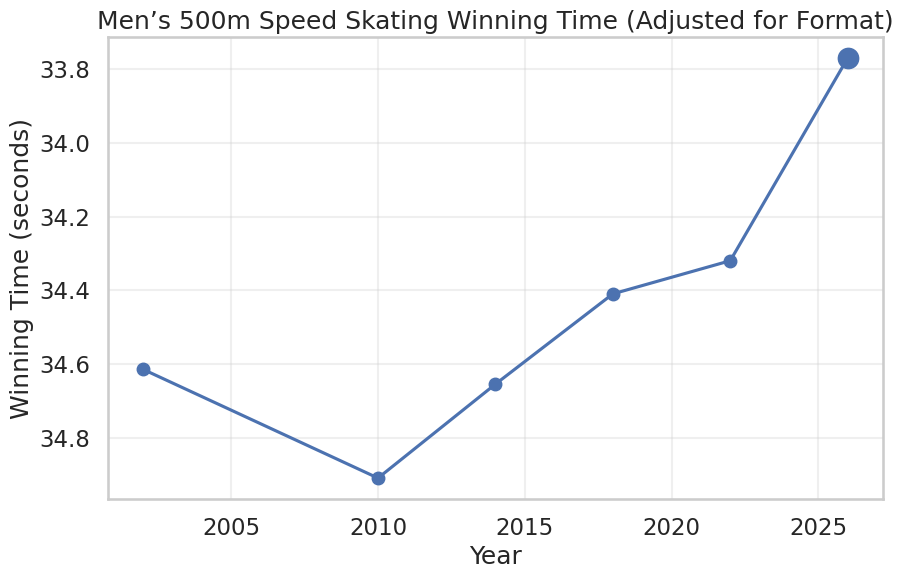

In [32]:
plt.figure(figsize=(10,6))

plt.plot(speed500_df["year"], speed500_df["adjusted_time"], marker="o")

plt.gca().invert_yaxis()
plt.title("Men’s 500m Speed Skating Winning Time (Adjusted for Format)")
plt.xlabel("Year")
plt.ylabel("Winning Time (seconds)")
plt.grid(True, alpha=0.3)

# Highlight 2026
r2026 = speed500_df[speed500_df["year"] == 2026].iloc[0]
plt.scatter([r2026["year"]], [r2026["adjusted_time"]], s=200)

plt.show()

## Key Moment: The 2026 500m Final

We zoom into a single event where an Olympic record was set.

Instead of looking at medal counts, we simulate the race itself
to understand how small the margins truly are.

In [33]:
# Re-scrape 2026 results table for men's 500m
year = 2026
url = speed500_urls[year]

html = requests.get(url, headers=headers).text
tables = pd.read_html(StringIO(html))

# Identify results table
result_table = None
for table in tables:
    cols = [str(c).lower() for c in table.columns]
    if "name" in cols and ("total" in cols or "time" in cols):
        result_table = table.copy()
        break

result_table.columns = [str(c).strip().lower() for c in result_table.columns]

# Use Total if present, else Time
time_col = "total" if "total" in result_table.columns else "time"

result_table["time_seconds"] = result_table[time_col].apply(time_to_seconds)

# Sort by fastest time
podium_2026 = result_table.sort_values("time_seconds").head(3)[
    ["name", "country", time_col, "time_seconds"]
]

podium_2026

,name,country,time,time_seconds
0,Jordan Stolz,United States,33.77,33.77
1,Jenning de Boo,Netherlands,33.88,33.88
2,Laurent Dubreuil,Canada,34.26,34.26


## visualizing the olympic record moment

In [34]:
gold_time = podium_2026.iloc[0]["time_seconds"]
silver_time = podium_2026.iloc[1]["time_seconds"]

margin = silver_time - gold_time

print(f"Gold Time: {gold_time:.2f} s")
print(f"Silver Time: {silver_time:.2f} s")
print(f"Margin of Victory: {margin:.3f} seconds")

Gold Time: 33.77 s
Silver Time: 33.88 s
Margin of Victory: 0.110 seconds


In [35]:
import numpy as np
import plotly.graph_objects as go

# --- Prepare podium data ---
pod = podium_2026.reset_index(drop=True).copy()
pod["place"] = ["Gold", "Silver", "Bronze"]
pod = pod[["place", "name", "time_seconds"]]
pod["time_seconds"] = pod["time_seconds"].astype(float)

race_distance = 500  # meters

# --- Timeline ---
t_end = float(pod["time_seconds"].max())
N_FRAMES = 160
times = np.linspace(0, t_end, N_FRAMES)

def position_at_time(t, finish_time):
    # constant speed; clamp at finish
    return min(race_distance, race_distance * (t / float(finish_time)))

# Medal dot colors (explicit)
color_map = {
    "Gold":   "#D4AF37",  # gold
    "Silver": "#C0C0C0",  # silver
    "Bronze": "#CD7F32"   # bronze
}

# Lane positions
lane_map = {"Gold": 3, "Silver": 2, "Bronze": 1}
pod["lane"] = pod["place"].map(lane_map)
pod["color"] = pod["place"].map(color_map)

# --- Base figure ---
fig = go.Figure()

# Initial state (t=0)
fig.add_trace(
    go.Scatter(
        x=[0, 0, 0],
        y=pod["lane"],
        mode="markers+text",
        text=pod["place"],
        textposition="middle right",
        marker=dict(
            size=20,
            color=pod["color"].tolist(),   # <-- medal colors
            line=dict(width=1, color="rgba(0,0,0,0.35)")
        ),
        hovertext=[
            f"{row.place}: {row['name']}<br>Finish: {row.time_seconds:.2f}s"
            for _, row in pod.iterrows()
        ],
        hoverinfo="text",
        showlegend=False,
    )
)

# --- Frames ---
frames = []
for t in times:
    xs = [position_at_time(t, ft) for ft in pod["time_seconds"].tolist()]
    hover = [
        f"{row.place}: {row['name']}<br>"
        f"Elapsed: {t:.2f}s<br>"
        f"Finish: {row.time_seconds:.2f}s<br>"
        f"Distance: {x:.1f}m / {race_distance}m"
        for (x, (_, row)) in zip(xs, pod.iterrows())
    ]

    frames.append(
        go.Frame(
            data=[
                go.Scatter(
                    x=xs,
                    y=pod["lane"],
                    marker=dict(
                        size=20,
                        color=pod["color"].tolist(),
                        line=dict(width=1, color="rgba(0,0,0,0.35)")
                    ),
                    hovertext=hover,
                    hoverinfo="text",
                    mode="markers+text",
                    text=pod["place"],
                    textposition="middle right",
                )
            ],
            name=f"{t:.2f}"
        )
    )

fig.frames = frames

# --- Finish line ---
fig.add_shape(
    type="line",
    x0=race_distance, x1=race_distance,
    y0=0.5, y1=3.5,
    line=dict(dash="dash")
)

# --- Layout (key: slider fully above plot + plot pushed down) ---
fig.update_layout(
    title="2026 Men's 500m — Podium Finish Replay (Start → Finish)",
    height=520,

    # Bigger top margin to create a true white band above plot
    margin=dict(l=60, r=30, t=210, b=60),

    xaxis=dict(
        title="Distance (meters)",
        range=[0, race_distance + 20]
    ),

    # Push plotting area down so nothing overlaps lanes
    yaxis=dict(
        range=[0.5, 3.5],
        tickmode="array",
        tickvals=[1, 2, 3],
        ticktext=["Bronze", "Silver", "Gold"],
        title="",
        domain=[0, 0.72]   # <-- plot occupies lower part only (more white space above)
    ),

    # Play/Pause top-right (in the white band)
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.98,
            y=1.45,
            xanchor="right",
            yanchor="top",
            buttons=[
                dict(
                    label="▶ Play",
                    method="animate",
                    args=[None, dict(
                        frame=dict(duration=40, redraw=True),
                        fromcurrent=True,
                        transition=dict(duration=0)
                    )]
                ),
                dict(
                    label="⏸ Pause",
                    method="animate",
                    args=[[None], dict(
                        frame=dict(duration=0, redraw=False),
                        mode="immediate",
                        transition=dict(duration=0)
                    )]
                )
            ],
        )
    ],

    # Slider moved higher so the scale is also in the white band
    sliders=[
        dict(
            x=0.08,
            y=1.36,       # <-- higher than before
            len=0.84,
            pad=dict(t=20),
            currentvalue=dict(
                prefix="Elapsed Time: ",
                suffix=" s",
                font=dict(size=20),
                visible=True
            ),
            steps=[
                dict(
                    method="animate",
                    args=[[f.name], dict(
                        mode="immediate",
                        frame=dict(duration=0, redraw=True),
                        transition=dict(duration=0)
                    )],
                    label=f.name
                )
                for f in fig.frames
            ],
        )
    ]
)

fig.show()

#Final Reflection

If you were advising an Olympic federation:

- Would you invest in building depth?
- Or concentrate resources on developing a superstar?

Data reveals patterns — but strategy determines outcomes.